# Эксперимент 05: 2D CNN на мел-спектрограмме

**Статья:** The recognition of speech defects using convolutional neural network (Распознавание дефектов речи с использованием сверточной нейронной сети) 2023

**Ссылка:** [https://acnsci.org/journal/index.php/cte/article/view/554/600](https://acnsci.org/journal/index.php/cte/article/view/554/600)

**Краткое описание модели:** Mel-спектрограмма как 2D-вход -> сверточная сеть Conv-BN-ReLU-Pool -> классификатор good/bad.

**Содержание статьи:** Статьи подтверждают эффективность 2D-CNN на time-frequency представлениях для аудиоклассификации. Для речевых дефектов важны локальные спектрально-временные паттерны, которые CNN выделяет автоматически. Эксперимент оценивает такой архитектурный бейзлайн на вашем датасете скороговорок.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import time
from joblib import Parallel, delayed
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils, train_utils
from shared.results_utils import save_result_csv
from model import get_model

## 1. Разбиение и извлечение мел-спектрограмм

In [ ]:
paths_train, paths_val, paths_test, y_train, y_val, y_test, letters_train, letters_val, letters_test = data_utils.get_splits()
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")
n_letters = letters_train.shape[1]

N_MELS = config.N_MELS
N_FRAMES = 320  # ~10 с при hop_length=512, sr=16k

def load_mel(path):
    mel = data_utils.extract_mel_spectrogram(path, max_frames=N_FRAMES)
    return mel[np.newaxis, ...]  # (1, n_mels, T)

def build_mel_matrix(paths, n_jobs=-1):
    rows = Parallel(n_jobs=n_jobs)(delayed(load_mel)(p) for p in paths)
    return np.stack(rows, axis=0)

print("Извлечение mel (train)...")
X_train_mel = build_mel_matrix(paths_train, n_jobs=-1)
print("Val...")
X_val_mel   = build_mel_matrix(paths_val, n_jobs=-1)
print("Test...")
X_test_mel  = build_mel_matrix(paths_test, n_jobs=-1)
print(f"Форма mel: (N, 1, {N_MELS}, {N_FRAMES})")

Train: 1942, Val: 417, Test: 417
Извлечение mel (train)...
Val...
Test...
Форма mel: (N, 1, 80, 320)


In [3]:
# Нормализация по каналу (mean/std по обучающей выборке)
mel_mean = X_train_mel.mean(axis=(0, 2, 3), keepdims=True)
mel_std  = X_train_mel.std(axis=(0, 2, 3), keepdims=True)
mel_std  = np.where(mel_std < 1e-6, 1.0, mel_std)
X_train_mel = (X_train_mel - mel_mean) / mel_std
X_val_mel   = (X_val_mel - mel_mean) / mel_std
X_test_mel  = (X_test_mel - mel_mean) / mel_std

## 2. DataLoader и модель

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

BATCH_SIZE = 32
train_ds = TensorDataset(
    torch.from_numpy(X_train_mel).float(),
    torch.from_numpy(letters_train).float(),
    torch.from_numpy(y_train).long(),
)
val_ds   = TensorDataset(torch.from_numpy(X_val_mel).float(), torch.from_numpy(letters_val).float(), torch.from_numpy(y_val).long())
test_ds  = TensorDataset(torch.from_numpy(X_test_mel).float(), torch.from_numpy(letters_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(device.type=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Device: cuda


In [5]:
model = get_model(n_mels=N_MELS, n_frames=N_FRAMES, num_classes=2, n_letters=n_letters, dropout=0.5).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {n_params}")

Параметров: 440018


## 3. Обучение

In [6]:
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = train_utils.get_lr_scheduler(
    optimizer, patience=config.LR_SCHEDULER_PATIENCE, factor=config.LR_SCHEDULER_FACTOR
)
early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
best_ckpt_path = exp_dir / "best_ckpt.pt"
best_f1 = -1.0

In [7]:
def eval_loader(loader):
    model.eval()
    correct, total = 0, 0
    all_pred, all_true = [], []
    with torch.no_grad():
        for x, letters, y in loader:
            x, letters, y = x.to(device), letters.to(device), y.to(device)
            logits = model(x, letters)
            pred = logits.argmax(dim=1)
            total += y.size(0)
            correct += (pred == y).sum().item()
            all_pred.append(pred.cpu().numpy())
            all_true.append(y.cpu().numpy())
    acc = correct / total
    return acc, np.concatenate(all_pred), np.concatenate(all_true)

N_EPOCHS = 50
train_losses, val_f1s = [], []

t0 = time.perf_counter()
for epoch in range(N_EPOCHS):
    model.train()
    epoch_losses = []
    for x, letters, y in train_loader:
        x, letters, y = x.to(device), letters.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x, letters), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.DEFAULT_GRAD_CLIP)
        optimizer.step()
        epoch_losses.append(loss.item())
    train_losses.append(np.mean(epoch_losses))
    _, vp, vt = eval_loader(val_loader)
    val_f1 = f1_score(vt, vp, average="macro")
    val_f1s.append(val_f1)
    if val_f1 > best_f1:
        best_f1 = val_f1
        train_utils.save_best_checkpoint(model, best_ckpt_path)
    scheduler.step(val_f1)
    print(f"Epoch {epoch+1}/{N_EPOCHS}  train_loss={train_losses[-1]:.4f}  val_f1_macro={val_f1:.4f}")
    if early_stopping.step(val_f1):
        print(f"Early stopping на эпохе {epoch+1}")
        break
train_time_sec = time.perf_counter() - t0
train_utils.load_best_checkpoint(model, best_ckpt_path, device)
print(f"Обучение заняло {train_time_sec:.1f} с. Загружен лучший чекпоинт (val_f1_macro={best_f1:.4f}).")

Epoch 1/50  train_loss=2.1961  val_f1_macro=0.6338
Epoch 2/50  train_loss=1.1419  val_f1_macro=0.6638
Epoch 3/50  train_loss=1.1193  val_f1_macro=0.5169
Epoch 4/50  train_loss=1.5804  val_f1_macro=0.6332
Epoch 5/50  train_loss=1.0702  val_f1_macro=0.6297
Epoch 6/50  train_loss=0.9852  val_f1_macro=0.7010
Epoch 7/50  train_loss=1.1492  val_f1_macro=0.6096
Epoch 8/50  train_loss=0.9650  val_f1_macro=0.5572
Epoch 9/50  train_loss=0.9878  val_f1_macro=0.6059
Epoch 10/50  train_loss=1.0373  val_f1_macro=0.3806
Epoch 11/50  train_loss=0.7806  val_f1_macro=0.6902
Epoch 12/50  train_loss=0.7988  val_f1_macro=0.5584
Epoch 13/50  train_loss=0.6907  val_f1_macro=0.6537
Epoch 14/50  train_loss=0.6229  val_f1_macro=0.6751
Epoch 15/50  train_loss=0.5786  val_f1_macro=0.6560
Epoch 16/50  train_loss=0.4897  val_f1_macro=0.6818
Early stopping на эпохе 16
Обучение заняло 57.1 с. Загружен лучший чекпоинт (val_f1_macro=0.7010).


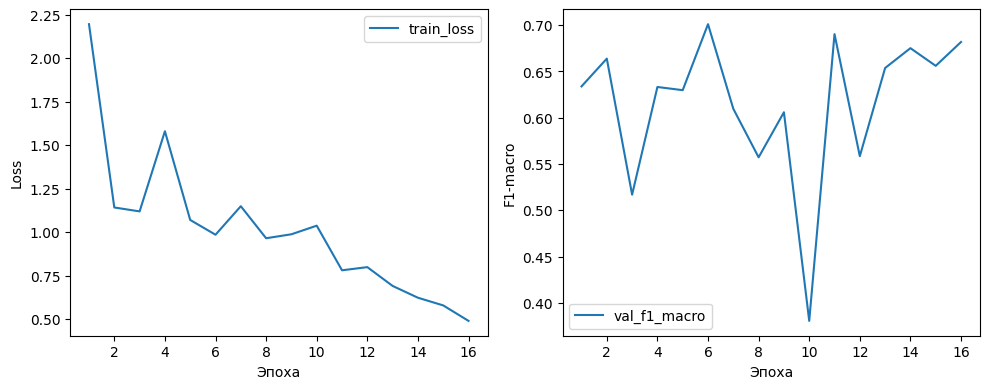

In [8]:
n_epochs_done = len(train_losses)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs_done + 1), train_losses, label="train_loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs_done + 1), val_f1s, label="val_f1_macro")
plt.xlabel("Эпоха")
plt.ylabel("F1-macro")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Оценка на тесте и метрики

In [9]:
model.eval()
all_logits = []
with torch.no_grad():
    for x, letters, _ in test_loader:
        x, letters = x.to(device), letters.to(device)
        all_logits.append(model(x, letters).cpu().numpy())
logits = np.concatenate(all_logits)
y_pred = np.argmax(logits, axis=1)
y_proba = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_bad   = f1_score(y_test, y_pred, pos_label=config.CLASS_BAD)
roc_auc  = roc_auc_score(y_test, y_proba)
precision_bad = precision_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)
recall_bad    = recall_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)

print(classification_report(y_test, y_pred, target_names=config.CLASS_NAMES))
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 (bad): {f1_bad:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")

metrics_table = pd.DataFrame([{
    "accuracy": accuracy, "f1_macro": f1_macro, "f1_bad": f1_bad,
    "roc_auc": roc_auc, "precision_bad": precision_bad, "recall_bad": recall_bad,
}])
print("\nТаблица метрик (тест):")
display(metrics_table)

              precision    recall  f1-score   support

        good       0.80      0.76      0.78       282
         bad       0.54      0.59      0.57       135

    accuracy                           0.71       417
   macro avg       0.67      0.68      0.67       417
weighted avg       0.71      0.71      0.71       417

Accuracy: 0.7074
F1 macro: 0.6732
F1 (bad): 0.5674
ROC-AUC:  0.7531

Таблица метрик (тест):


,accuracy,f1_macro,f1_bad,roc_auc,precision_bad,recall_bad
0,0.707434,0.673181,0.567376,0.753086,0.544218,0.592593


## 5. Запись метрик в общий файл

In [ ]:
save_result_csv(
    exp_dir=exp_dir,
    experiment_id="exp_05_2d_cnn",
    experiment_name="2D CNN на mel-спектрограмме",
    model="2D CNN (mel)",
    accuracy=accuracy,
    f1_macro=f1_macro,
    f1_bad=f1_bad,
    roc_auc=roc_auc,
    precision_bad=precision_bad,
    recall_bad=recall_bad,
    notes=f"n_mels={N_MELS}, n_frames={N_FRAMES}, epochs={N_EPOCHS}, batch={BATCH_SIZE}",
    num_params=n_params,
    train_time_sec=train_time_sec,
)